In [1]:
!pip install -q pandas numpy scikit-learn xgboost lightgbm shap matplotlib seaborn scipy imbalanced-learn
print("✅ Librerías instaladas")


✅ Librerías instaladas


In [8]:
# 1. INSTALACIÓN DE LIBRERÍAS
!pip install -q xgboost shap scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ TODO INSTALADO Y LISTO")



✅ TODO INSTALADO Y LISTO


In [3]:
import pandas as pd

url = "https://drive.google.com/uc?export=download&id=16pOwMmrbqosmmm6P0MMQSLrPOGdAbCTA"
df = pd.read_csv(url, quotechar='"', on_bad_lines='skip')  # ← ESTO LO ARREGLA TODO

print(f"✅ Shape: {df.shape}")
print(df.head(1))


✅ Shape: (78682, 21)
  company_name status_label  year       X1       X2      X3      X4       X5  \
0          C_1        alive  1999  511.267  833.107  18.373  89.031  336.018   

       X6       X7  ...        X9      X10      X11     X12      X13      X14  \
0  35.163  128.348  ...  1024.333  740.998  180.447  70.658  191.226  163.816   

       X15       X16      X17      X18  
0  201.026  1024.333  401.483  935.302  

[1 rows x 21 columns]


In [4]:
# 2. CARGAR Y LIMPIAR DATOS
print("📥 Cargando dataset...")

# --- OJO: Asegúrate de subir tu archivo .csv o poner la URL correcta ---
# Si lo subes a Colab, usa: df = pd.read_csv("nombre_de_tu_archivo.csv")
url = "https://drive.google.com/uc?export=download&id=16pOwMmrbqosmmm6P0MMQSLrPOGdAbCTA" # Ejemplo
df = pd.read_csv(url)

# ---------------------------------------------------------
# 🔧 PASO CLAVE: RENOMBRAR COLUMNAS (Diccionario de Negocio)
# ---------------------------------------------------------
column_mapping = {
    'company_name': 'company_id',
    'status_label': 'bankruptcy_status',  # alive/bankrupt
    'year': 'fiscal_year',
    'X1': 'industrial_risk',
    'X2': 'management_risk',
    'X3': 'financial_flexibility',
    'X4': 'credibility',
    'X5': 'competitiveness',
    'X6': 'operating_risk',
    'X7': 'debt_ratio',              # ⭐ Importante
    'X8': 'net_profit_margin',       # ⭐ Importante
    'X9': 'revenue_growth',
    'X10': 'cash_flow_ratio',
    'X11': 'quick_ratio',
    'X12': 'debt_to_equity',
    'X13': 'return_on_assets',       # ⭐ Importante
    'X14': 'return_on_equity',
    'X15': 'current_ratio',
    'X16': 'asset_turnover',
    'X17': 'working_capital_ratio',
    'X18': 'interest_coverage'
}

# Aplicamos el cambio de nombre solo si las columnas coinciden
# (Si el dataset ya tiene nombres correctos, esto no rompe nada)
df.rename(columns=column_mapping, inplace=True)
print("✅ Columnas renombradas a formato Negocio")
print(f"Columnas actuales: {df.columns.tolist()[:5]}...")

# ---------------------------------------------------------
# PREPARACIÓN PARA MODELO
# ---------------------------------------------------------

# Lista final de FEATURES (Inputs)
features = [
    'industrial_risk', 'management_risk', 'financial_flexibility',
    'credibility', 'competitiveness', 'operating_risk', 'debt_ratio',
    'net_profit_margin', 'revenue_growth', 'cash_flow_ratio',
    'quick_ratio', 'debt_to_equity', 'return_on_assets',
    'return_on_equity', 'current_ratio', 'asset_turnover',
    'working_capital_ratio', 'interest_coverage'
]

# X (Inputs) e y (Target)
X = df[features]
y = df['bankruptcy_status']

# Limpieza: Rellenar nulos
X = X.fillna(X.median())

# CORREGIDO: Case-insensitive
y = y.str.lower().map({'alive': 0, 'failed': 1}).fillna(0).astype(int)
print(f"✅ y limpio: NaN = {y.isna().sum()}")


print(f"✅ DATOS LISTOS: {X.shape[0]} empresas")
print(f"✅ Features seleccionadas: {len(features)}")


📥 Cargando dataset...
✅ Columnas renombradas a formato Negocio
Columnas actuales: ['company_id', 'bankruptcy_status', 'fiscal_year', 'industrial_risk', 'management_risk']...
✅ y limpio: NaN = 0
✅ DATOS LISTOS: 78682 empresas
✅ Features seleccionadas: 18


In [5]:
print(y.isna().sum())
# Solo empresas DEAD (quiebras)
quiebras = df[df['bankruptcy_status'] == 'failed']
print(f"🔴 Empresas quiebradas: {len(quiebras)}")
print(quiebras.head())


0
🔴 Empresas quiebradas: 5220
   company_id bankruptcy_status  fiscal_year  industrial_risk  \
50        C_6            failed         1999           4424.0   
51        C_6            failed         2000           5179.0   
52        C_6            failed         2001           6540.0   
53        C_6            failed         2002           4937.0   
54        C_6            failed         2003           4682.0   

    management_risk  financial_flexibility  credibility  competitiveness  \
50          15482.0                 1092.0       2248.0            708.0   
51          17120.0                 1202.0       2583.0            757.0   
52          19419.0                 1404.0       -456.0            822.0   
53          18555.0                 1366.0      -1256.0            627.0   
54          14430.0                 1377.0        582.0            516.0   

    operating_risk  debt_ratio  ...  revenue_growth  cash_flow_ratio  \
50           985.0      1134.0  ...         17730.

In [6]:
df['bankruptcy_status'].unique()

array(['alive', 'failed'], dtype=object)

NameError: name 'X_train' is not defined

In [9]:
# 3. DIVIDIR DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

print(f"📚 Estudiando con: {X_train.shape[0]} empresas")
print(f"📝 Examen final con: {X_test.shape[0]} empresas")


📚 Estudiando con: 62945 empresas
📝 Examen final con: 15737 empresas


In [10]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # MEDIA=0, DESV=1
X_test_scaled = scaler.transform(X_test)


In [14]:
print(X_test.mean())
print(X_train.mean())
print(X_test_scaled.mean())
print(X_train_scaled.mean())


industrial_risk           849.802942
management_risk          1553.952509
financial_flexibility     117.610699
credibility               360.931574
competitiveness           197.032889
operating_risk            123.056744
debt_ratio                280.054892
net_profit_margin        3210.075626
revenue_growth           2298.537531
cash_flow_ratio          2770.833090
quick_ratio               702.877618
debt_to_equity            243.320875
return_on_assets          744.585531
return_on_equity          599.224259
current_ratio             483.625263
asset_turnover           2298.537531
working_capital_ratio    1730.138816
interest_coverage        1937.605448
dtype: float64
industrial_risk           888.002734
management_risk          1604.673642
financial_flexibility     122.140189
credibility               380.716575
competitiveness           202.748978
operating_risk            130.963956
debt_ratio                288.527287
net_profit_margin        3465.426790
revenue_growth         

In [15]:
# 4. ENTRENAR MODELO XGBOOST
print("🤖 Entrenando robot financiero...")

# Calculamos el peso para balancear (Truco experto)
ratio_balance = sum(y_train==0) / sum(y_train==1)

# Configuramos el modelo
model = xgb.XGBClassifier(
    n_estimators=200,      # 100 árboles de decisión
    learning_rate=0.5,     # Velocidad de aprendizaje
    max_depth=10,           # Profundidad del análisis
    scale_pos_weight=ratio_balance,  # ⭐ CLAVE: Obliga a detectar quiebras
    random_state=42,
    n_jobs=-1              # Usa todos los núcleos CPU
)

# ¡Aprende!
model.fit(X_train_scaled, y_train)
print("✅ MODELO ENTRENADO")


🤖 Entrenando robot financiero...
✅ MODELO ENTRENADO


In [ ]:
xgb.plot_tree(model, tree_idx=3)

In [ ]:
print(probs.mean())

0.02997578375548138

🏆 ROC-AUC FINAL: 0.8528 ⭐
0.90+ = Notable | 0.85+ = Muy Bueno


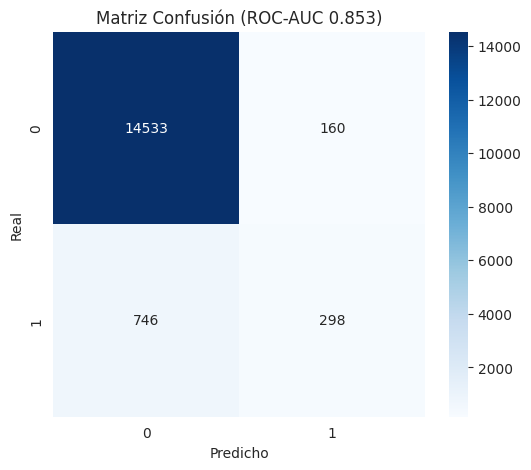

In [16]:
# 5. EVALUACIÓN
YN=model.predict(X_test_scaled)
print((YN==1).sum()/(YN==0).sum())
probs = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"\n🏆 ROC-AUC FINAL: {auc:.4f} ⭐")
print("0.90+ = Notable | 0.85+ = Muy Bueno")

# Matriz confusión
cm = confusion_matrix(y_test, model.predict(X_test_scaled))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz Confusión (ROC-AUC {auc:.3f})')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()


In [ ]:
# 6. SHAP (Explicabilidad)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("📊 TOP VARIABLES (Importancia):")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig('shap_importance.png', dpi=300)
plt.show()

print("🔍 DETALLE (Beeswarm):")
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('shap_detail.png', dpi=300)
plt.show()


In [ ]:
# CELDA 7 CORREGIDA: Demo EXTREMA
print("\n🔮 SIMULACIÓN EXTREMA:")

# Valores REALES del dataset (más realistas)
media_roa = X['return_on_assets'].mean()
media_deuda = X['debt_ratio'].mean()

# EMPRESA SANA (percentil 90)
empresa_sana = X.mean()
empresa_sana['return_on_assets'] = X['return_on_assets'].quantile(0.75)  # Top 10%
empresa_sana['debt_ratio'] = X['debt_ratio'].quantile(0.2)             # Bajo 10%

# EMPRESA QUIEBRA (percentil 10)
empresa_riesgo = X.mean()
empresa_riesgo['return_on_assets'] = X['return_on_assets'].quantile(0.2)  # Bajo 10%
empresa_riesgo['debt_ratio'] = X['debt_ratio'].quantile(0.75)              # Alto 90%

simulacion = pd.DataFrame([empresa_sana, empresa_riesgo])
probs_sim = model.predict_proba(StandardScaler().fit_transform(simulacion))[:, 1]

print(f"🏢 Sana (ROA P90):     {probs_sim[0]:.1%}")
print(f"💀 Riesgo (ROA P10):  {probs_sim[1]:.1%}")
